# 02 - Exploratory Data Analysis

**Phase 1, Step 1.2 - EDA**

Run this AFTER `01_Dataset_Loading.ipynb`. Analyzes class distribution, image sizes, objects-per-image, and visualizes sample images with their annotated bounding boxes.

### 1. Mount Drive and load configuration

In [1]:
!pip install -q datasets pyyaml tqdm scikit-learn matplotlib pandas opencv-python-headless pillow

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os

# ---------------------------------------------------------------------------
# Project configuration - shared across every SmartVision AI notebook.
# All notebooks read/write under this same Google Drive folder so that
# work done in one notebook (e.g. dataset collection) is available to the
# next one (e.g. training), even across separate Colab sessions.
# ---------------------------------------------------------------------------
BASE_DIR = "/content/drive/MyDrive/SmartVisionAI"

RAW_DATA_DIR = os.path.join(BASE_DIR, "raw_data")
RAW_IMAGES_DIR = os.path.join(RAW_DATA_DIR, "images")
RAW_ANNOTATIONS_PATH = os.path.join(RAW_DATA_DIR, "annotations.json")

CLASSIFICATION_DIR = os.path.join(BASE_DIR, "classification")
CLASSIFICATION_TRAIN_DIR = os.path.join(CLASSIFICATION_DIR, "train")
CLASSIFICATION_VAL_DIR = os.path.join(CLASSIFICATION_DIR, "val")
CLASSIFICATION_TEST_DIR = os.path.join(CLASSIFICATION_DIR, "test")

DETECTION_DIR = os.path.join(BASE_DIR, "detection")
DETECTION_IMAGES_DIR = os.path.join(DETECTION_DIR, "images")
DETECTION_LABELS_DIR = os.path.join(DETECTION_DIR, "labels")
DETECTION_YAML_PATH = os.path.join(DETECTION_DIR, "data.yaml")

MODELS_DIR = os.path.join(BASE_DIR, "models")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")

for d in [BASE_DIR, RAW_DATA_DIR, RAW_IMAGES_DIR, CLASSIFICATION_DIR, DETECTION_DIR, MODELS_DIR, OUTPUTS_DIR]:
    os.makedirs(d, exist_ok=True)

# The 25 selected COCO classes (must match COCO category names exactly)
SELECTED_CLASSES = [
    # Vehicles (6)
    "car", "truck", "bus", "motorcycle", "bicycle", "airplane",
    # Person (1)
    "person",
    # Outdoor (3)
    "traffic light", "stop sign", "bench",
    # Animals (6)
    "dog", "cat", "horse", "bird", "cow", "elephant",
    # Kitchen & food (5)
    "bottle", "cup", "bowl", "pizza", "cake",
    # Furniture & indoor (4)
    "chair", "couch", "bed", "potted plant",
]
assert len(SELECTED_CLASSES) == 25

CLASS_TO_IDX = {name: i for i, name in enumerate(SELECTED_CLASSES)}
IDX_TO_CLASS = {i: name for i, name in enumerate(SELECTED_CLASSES)}

def safe_name(class_name):
    return class_name.replace(" ", "_")

IMAGES_PER_CLASS = 350        # -> 8,750 images total (up from 100/class to fight overfitting)
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

CLS_IMG_SIZE = 224            # Classification input resolution (single-resolution throughout)
FINE_TUNE_IMG_SIZE = 384      # Unused by classifier training (reverted to single-resolution); kept for compatibility
YOLO_IMG_SIZE = 640
BATCH_SIZE = 32                # Stage 1 batch size
BATCH_SIZE_STAGE2 = 16         # Smaller batch at 384x384 to fit GPU memory (~2.9x pixels/image)

HF_DATASET_NAME = "detection-datasets/coco"

print("BASE_DIR:", BASE_DIR)
print("Classes:", len(SELECTED_CLASSES))


BASE_DIR: /content/drive/MyDrive/SmartVisionAI
Classes: 25


In [5]:
!ls -la /content/drive/MyDrive/SmartVisionAI/
!ls -la /content/drive/MyDrive/SmartVisionAI/raw_data/

total 20
drwx------ 2 root root 4096 Jul 18 05:48 classification
drwx------ 2 root root 4096 Jul 18 05:48 detection
drwx------ 2 root root 4096 Jul 18 05:48 models
drwx------ 2 root root 4096 Jul 18 05:48 outputs
drwx------ 2 root root 4096 Jul 18 05:48 raw_data
total 1481
-rw------- 1 root root 1510978 Jul 18 05:49 annotations.json
drwx------ 2 root root    4096 Jul 18 05:48 images
-rw------- 1 root root     991 Jul 18 05:49 metadata.json


In [6]:
import json
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from collections import Counter

with open(RAW_ANNOTATIONS_PATH) as f:
    annotations = json.load(f)
print(f"Loaded {len(annotations)} annotated images.")


Loaded 3087 annotated images.


### 2. Class distribution (by bounding box count, not image count)

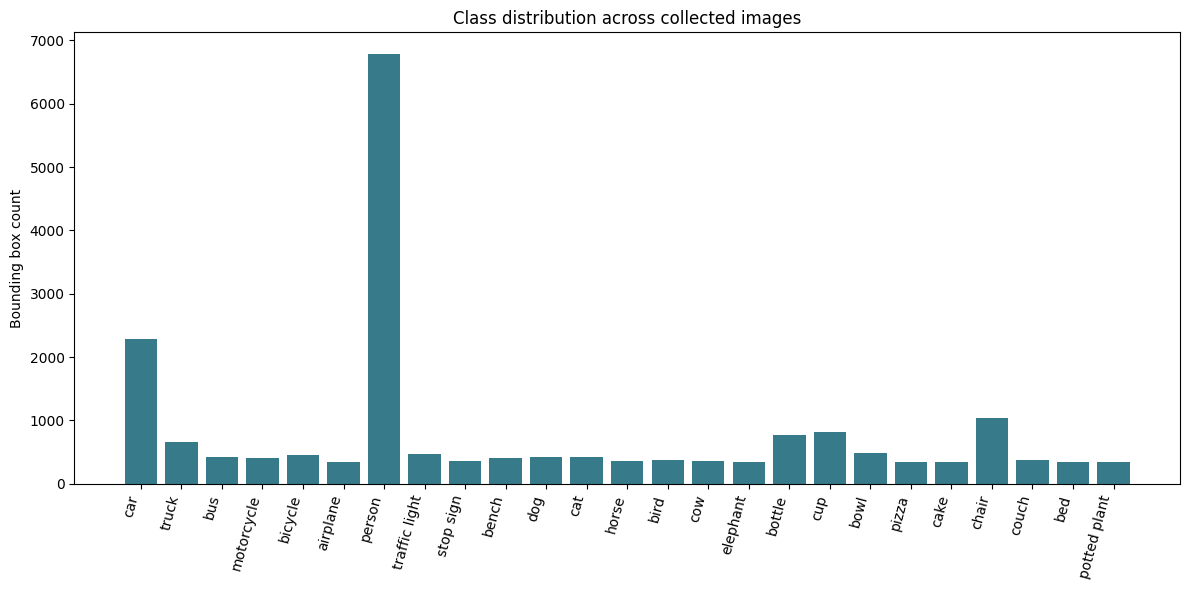

In [7]:
class_counts = Counter()
for ann in annotations:
    for box in ann["boxes"]:
        class_counts[box["class"]] += 1

counts_ordered = [class_counts.get(c, 0) for c in SELECTED_CLASSES]

plt.figure(figsize=(12, 6))
plt.bar(SELECTED_CLASSES, counts_ordered, color="#377a8a")
plt.xticks(rotation=75, ha="right")
plt.ylabel("Bounding box count")
plt.title("Class distribution across collected images")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "eda_class_distribution.png"), dpi=150)
plt.show()


### 3. Image size distribution

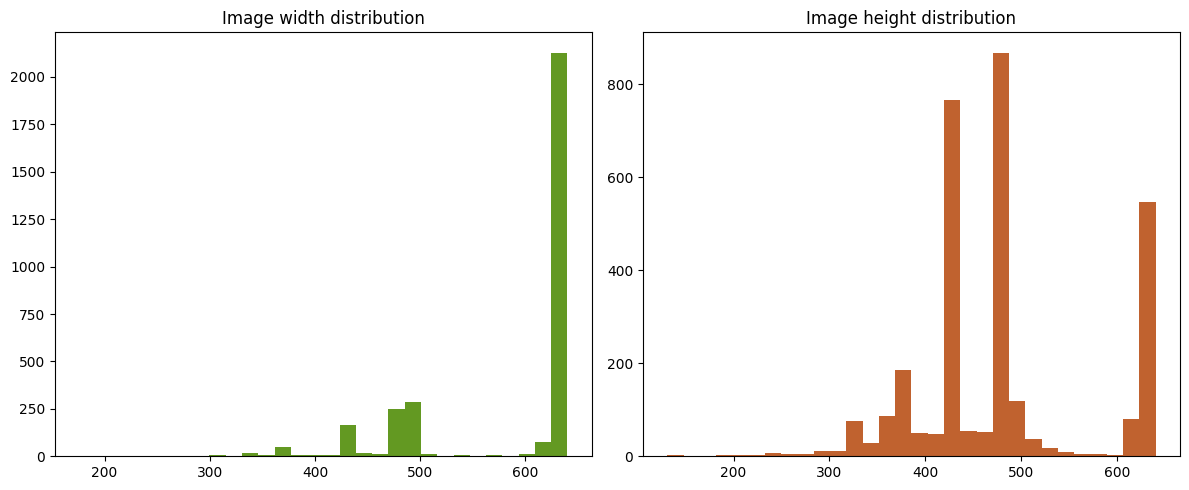

Width  - min=176 max=640 mean=589
Height - min=131 max=640 mean=479


In [8]:
widths = [a["width"] for a in annotations]
heights = [a["height"] for a in annotations]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(widths, bins=30, color="#639922")
axes[0].set_title("Image width distribution")
axes[1].hist(heights, bins=30, color="#c0622f")
axes[1].set_title("Image height distribution")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "eda_image_sizes.png"), dpi=150)
plt.show()

print(f"Width  - min={min(widths)} max={max(widths)} mean={sum(widths)/len(widths):.0f}")
print(f"Height - min={min(heights)} max={max(heights)} mean={sum(heights)/len(heights):.0f}")


### 4. Objects-per-image distribution

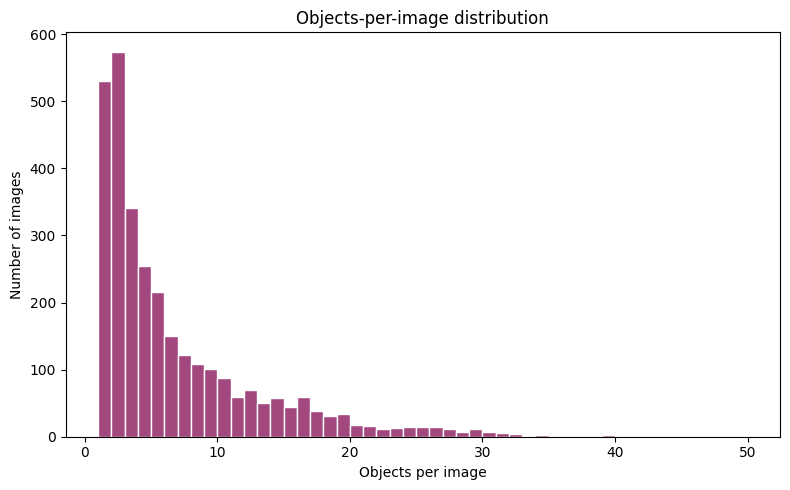

Average objects/image: 6.40


In [9]:
objs_per_image = [len(a["boxes"]) for a in annotations]

plt.figure(figsize=(8, 5))
plt.hist(objs_per_image, bins=range(1, max(objs_per_image) + 2), color="#a3487e", edgecolor="white")
plt.xlabel("Objects per image")
plt.ylabel("Number of images")
plt.title("Objects-per-image distribution")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "eda_objects_per_image.png"), dpi=150)
plt.show()

print(f"Average objects/image: {sum(objs_per_image)/len(objs_per_image):.2f}")


### 5. Sample images with bounding box annotations

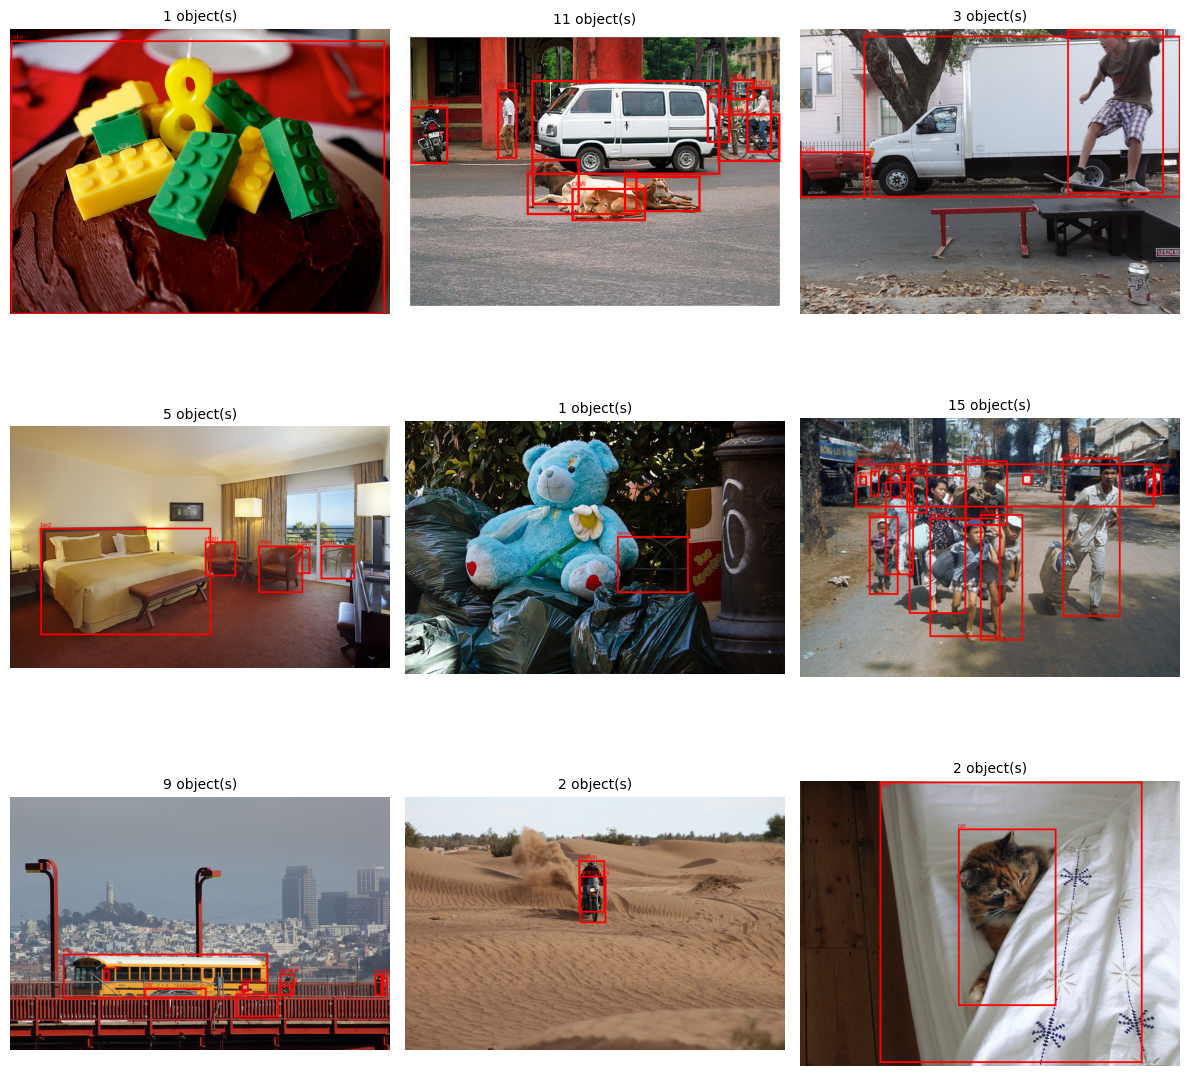

In [10]:
# NOTE: detection-datasets/coco stores "bbox" as [x_min, y_min, x_max, y_max]
# (corner format), NOT the original COCO [x, y, width, height] format. This was
# confirmed empirically - see the format-diagnostic check in the project README.
import random
random.seed(42)
samples = random.sample(annotations, min(9, len(annotations)))

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, ann in zip(axes.flat, samples):
    img = Image.open(os.path.join(RAW_IMAGES_DIR, ann["file"])).convert("RGB")
    draw = ImageDraw.Draw(img)
    for box in ann["boxes"]:
        x1, y1, x2, y2 = box["bbox"]  # x_min, y_min, x_max, y_max
        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        draw.text((x1, max(0, y1 - 12)), box["class"], fill="red")
    ax.imshow(img)
    ax.set_title(f"{len(ann['boxes'])} object(s)", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "eda_sample_grid.png"), dpi=150)
plt.show()


**Next notebook:** `03_Data_Preprocessing_Classification.ipynb` crops each object out of these images to build the classification dataset.